# Black–Scholes Options Pricing on SPY

An implementation and stress-test of the Black–Scholes–Merton model, applied to real SPY (S&P 500 ETF) data.

The numerical machinery lives in the `bsm` package (see `bsm/`) and is covered by a test suite in `tests/`. This notebook is the **narrative layer**: it explains the model, exercises the library, and documents where the theory parts company with the market.

**Contents**
1. Data - spot, realised volatility, risk-free rate, dividend yield
2. The model - the five inputs, the assumptions, the closed form
3. Interactive pricing - dials for $\sigma$ and $r$
4. The Greeks - behaviour across strike and time
5. Implied volatility - inversion and its failure modes
6. Pricing-method comparison - closed form vs. binomial tree vs. Monte Carlo
7. The implied volatility surface - skew, smile and term structure
8. What breaks in reality - constant vol, fat tails, jumps
9. Summary and extensions

> **Offline behaviour:** every data call attempts live yfinance first and falls back to synthetic but realistic data if the network is unavailable, so the notebook always runs end to end. A `live` flag records which path was taken, synthetic results are never presented as market data.

In [83]:
import sys, warnings
warnings.filterwarnings("ignore")

# Allow running from notebooks/ without installing the package
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D  # registers the 3d projection

from bsm import (
    bs_price, bs_greeks, implied_vol,
    binomial_price, mc_price,
    load_underlying, build_iv_surface,
)

plt.rcParams.update({
    "figure.figsize": (11, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
np.random.seed(42)

## 1. The five inputs

Black–Scholes prices a European option from five inputs, plus a sixth for dividend payers like SPY:

| Symbol | Input | Source | Observable? |
|---|---|---|---|
| $S$ | Spot price | Market quote | Yes |
| $K$ | Strike | Contract terms | Yes |
| $T$ | Time to expiry (years) | Contract terms | Yes |
| $r$ | Risk-free rate (cont. compounded) | T-bill / SOFR curve | Yes |
| $\sigma$ | Volatility of returns | Estimated or implied | No |
| $q$ | Continuous dividend yield | Trailing dividends (approximation) | Approximately |

The asymmetry in that last column is the most important fact about the model. Four inputs are read off a screen; $\sigma$ is a *forecast*. Two traders can agree on $S, K, T, r$ and still disagree violently on an option's value. This is why options markets are, in practice, **volatility markets**, and why Section 5 is where the model earns its keep.

The cell below estimates a *realised* volatility from SPY history. It is backward-looking; the market's forward-looking $\sigma$ will generally differ, and Section 7 shows it isn't even a single number.

SPY  [live (yfinance)]
  spot           764.29
  realised vol   16.43%  (annualised, daily log returns)
  risk-free r    3.91%
  div yield q    1.21%
  observations   501


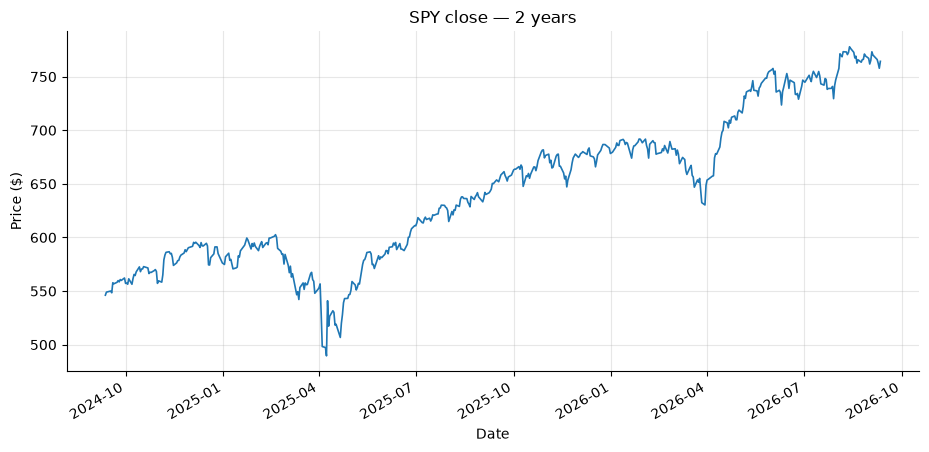

In [84]:
snap = load_underlying("SPY", period="2y")
print(snap.summary())

S0, r0, q0 = snap.spot, snap.risk_free, snap.div_yield
realized_vol = snap.realized_vol
log_ret = snap.log_returns

ax = snap.history["Close"].plot(title=f"{snap.ticker} close — 2 years", lw=1.2)
ax.set_ylabel("Price ($)")
plt.show()

## 2. The model and its assumptions

Under the risk-neutral measure the underlying is assumed to follow Geometric Brownian Motion (GBM):

$$ dS_t = \mu \,S_t\,dt + \sigma\,S_t\,dW_t, \quad \text {where }  \mu = (r-q)$$

so log-returns are normally distributed with *constant* volatility. A no-arbitrage hedging argument then gives:

$$C = S e^{-qT} N(d_1) - K e^{-rT} N(d_2), \qquad P = K e^{-rT} N(-d_2) - S e^{-qT} N(-d_1)$$

$$d_1 = \frac{\ln(S/K) + (r - q + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

**The assumptions, explicitly:**

1. **Constant volatility** - $\sigma$ is a single known number for the option's whole life.
2. **Log-normal returns, no jumps** - prices diffuse continuously.
3. **Constant risk-free rate**, with unlimited borrowing and lending at it.
4. **Frictionless markets** - no costs, no spread, continuous trading, no short-sale constraints.
5. **Continuous hedging** of the replicating portfolio.
6. **European exercise** - fine for index options, wrong for most American single-stock options.
7. **Known continuous dividend yield.**

Every one is false in practice. Assumptions 1 and 2 fail in ways *visible in market prices*  (Sections 7 and 8). The model survives not because its assumptions hold but because it works as a **quoting convention and interpolation device**: prices are converted to implied vols, risk and intuition live in vol space, and the model's known failures get absorbed into the surface itself.

In [85]:
# Regression check against the textbook benchmark (also asserted in tests/test_analytical.py)
c_ref = float(bs_price(100, 100, 1.0, 0.05, 0.20))
p_ref = float(bs_price(100, 100, 1.0, 0.05, 0.20, kind="put"))
parity = (c_ref - p_ref) - (100 - 100 * np.exp(-0.05))
print(f"Call {c_ref:.4f} (textbook 10.4506) | Put {p_ref:.4f} (5.5735) | parity residual {parity:.1e}")

Call 10.4506 (textbook 10.4506) | Put 5.5735 (5.5735) | parity residual 0.0e+00


In [86]:
# Verify the analytical Greeks against central finite differences.
# The test suite does this across a parameter grid; here we show one case explicitly.
#
# Note the step sizes are scaled to each input's magnitude. A fixed absolute step
# is a trap for gamma: the second difference divides by h^2, so with spot near 500
# a step of 1e-5 loses most of its significant digits to cancellation. The optimal
# step for a second difference is ~eps^(1/4) relative, not eps^(1/2).
S, K, T, r, sig = S0, S0, 0.5, r0, realized_vol
g = bs_greeks(S, K, T, r, sig, q0)
px = lambda **kw: float(bs_price(**{**dict(S=S, K=K, T=T, r=r, sigma=sig, q=q0), **kw}))
base = px()
hS, hs, hT, hr = S * 1e-4, 1e-5, 1e-5, 1e-6
fd = {
    "delta": (px(S=S+hS) - px(S=S-hS)) / (2*hS),
    "gamma": (px(S=S+hS) - 2*base + px(S=S-hS)) / hS**2,
    "vega":  (px(sigma=sig+hs) - px(sigma=sig-hs)) / (2*hs),
    "theta": -(px(T=T+hT) - px(T=T-hT)) / (2*hT),
    "rho":   (px(r=r+hr) - px(r=r-hr)) / (2*hr),
}
check = pd.DataFrame({"analytical": {k: float(g[k]) for k in fd}, "finite_diff": fd})
check["rel_error"] = ((check.analytical - check.finite_diff) / check.analytical).abs()
print(check.to_string(float_format=lambda x: f"{x:,.8f}"))
assert (check.rel_error < 1e-4).all(), "Greek mismatch — check the derivations"

        analytical  finite_diff  rel_error
delta   0.56570432   0.56570431 0.00000002
gamma   0.00439916   0.00439916 0.00000006
vega  211.06897050 211.06897049 0.00000000
theta -44.76243144 -44.76243144 0.00000000
rho   196.04484372 196.04484370 0.00000000


## 3. Interactive pricing — dials for $\sigma$ and $r$

Drag the sliders. Two things to internalise:

- **Volatility moves option prices a lot.** Calls *and* puts gain value as $\sigma$ rises: more uncertainty means more upside for the holder while the downside stays capped at the premium. That derivative is vega.
- **The rate moves prices modestly and asymmetrically.** Higher $r$ raises calls (the strike you'll pay is discounted harder) and lowers puts. Rho is small for short-dated options and material for LEAPS.

Dashed lines are intrinsic value; the gap to the curve is **time value**, which is where $\sigma$, $T$ and $r$ live.

*Sliders in §3 require `ipywidgets` and a live kernel. Run locally with jupyter lab. A static version of the same plot is embedded below the widget so the section reads correctly on GitHub.*

interactive(children=(FloatSlider(value=0.16427375271300199, description='sigma', max=0.8, min=0.05, readout_f…

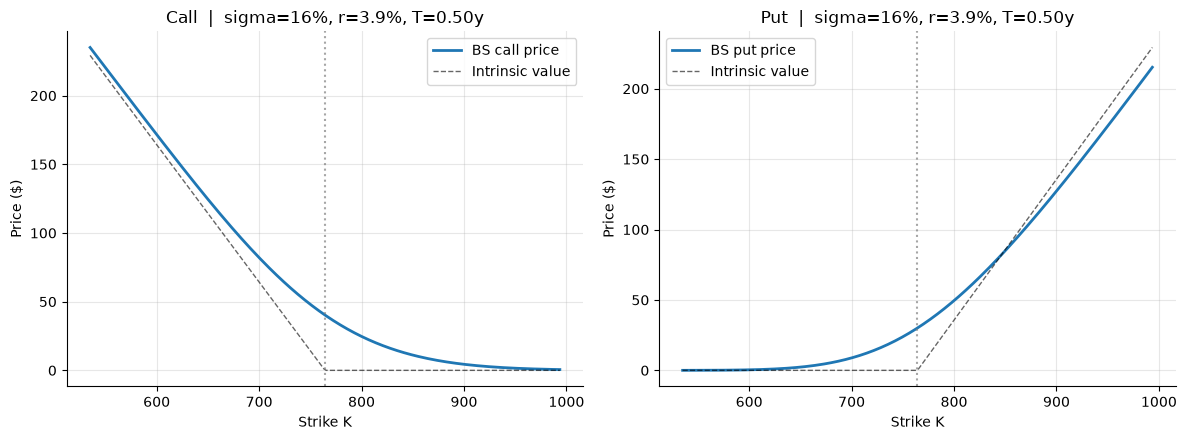

In [87]:
strikes = np.linspace(0.7 * S0, 1.3 * S0, 200)

def plot_prices(sigma=realized_vol, r=r0, T_years=0.5):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, kind in zip(axes, ["call", "put"]):
        price = bs_price(S0, strikes, T_years, r, sigma, q0, kind)
        intrinsic = np.maximum(S0 - strikes, 0) if kind == "call" else np.maximum(strikes - S0, 0)
        ax.plot(strikes, price, lw=2, label=f"BS {kind} price")
        ax.plot(strikes, intrinsic, "k--", lw=1, alpha=0.6, label="Intrinsic value")
        ax.axvline(S0, color="grey", ls=":", alpha=0.7)
        ax.set_title(f"{kind.capitalize()}  |  sigma={sigma:.0%}, r={r:.1%}, T={T_years:.2f}y")
        ax.set_xlabel("Strike K"); ax.set_ylabel("Price ($)"); ax.legend()
    plt.tight_layout()
    plt.show()

try:
    from ipywidgets import interact, FloatSlider
    interact(
        plot_prices,
        sigma=FloatSlider(value=realized_vol, min=0.05, max=0.80, step=0.01,
                          description="sigma", readout_format=".0%"),
        r=FloatSlider(value=r0, min=0.0, max=0.10, step=0.0025,
                      description="r", readout_format=".2%"),
        T_years=FloatSlider(value=0.5, min=0.05, max=2.0, step=0.05, description="T (years)"),
    )
except ImportError:
    print("ipywidgets unavailable: static grid instead")
    for s_ in [0.10, realized_vol, 0.40]:
        plot_prices(sigma=s_)

plot_prices(sigma=realized_vol, r=r0, T_years=0.5)

## 4. The Greeks

Each Greek is a partial derivative of the option price, a sensitivity to one input, holding the rest fixed. They are the working language of options risk: a desk doesn't think "I own 500 calls", it thinks "I'm long 12,000 delta, long 900 gamma, short 40k theta a day, long 150k vega".

| Greek | Definition | Measures | Use |
|---|---|---|---|
| **Delta** $\partial V/\partial S$ | Change per \$1 move in spot | Directional exposure | Hedge ratio: sell $\Delta$ shares per call to be locally market-neutral |
| **Gamma** $\partial^2 V/\partial S^2$ | Rate of change of delta | Convexity, hedge instability | High gamma ⇒ constant rebalancing; peaks ATM near expiry |
| **Vega** $\partial V/\partial \sigma$ | Change per unit of vol | Volatility exposure | The P&L of a vol trade; largest ATM, grows roughly with $\sqrt{T}$ |
| **Theta** $\partial V/\partial t$ | Decay per unit time | Cost of holding optionality | Long options bleed theta; it's the rent paid for gamma |
| **Rho** $\partial V/\partial r$ | Change per unit of rate | Rate exposure | Small for short-dated; material for LEAPS |

Delta is often described as the risk-neutral probability of finishing in the money. That is $N(d_2)$; call delta is $e^{-qT}N(d_1)$. 
The two are close for short-dated near-the-money options, which is why the shorthand survives, but they are different quantities and the gap widens with maturity and volatility.

Two structural relationships worth carrying around:

- **Gamma and theta are twins with opposite signs.** The Black–Scholes PDE states it exactly: $\theta + \tfrac{1}{2}\sigma^2 S^2 \Gamma + (r-q)S\Delta = rV$. For a delta-hedged book, expected theta bleed offsets expected gamma gains. 
You cannot be long convexity for free. (`tests/test_analytical.py::test_bs_pde_is_satisfied` asserts this residual is zero.)
- **Gamma and vega concentrate at the money; delta saturates.** Deep ITM options behave like the stock (delta → 1, everything else → 0); deep OTM options behave like nothing.

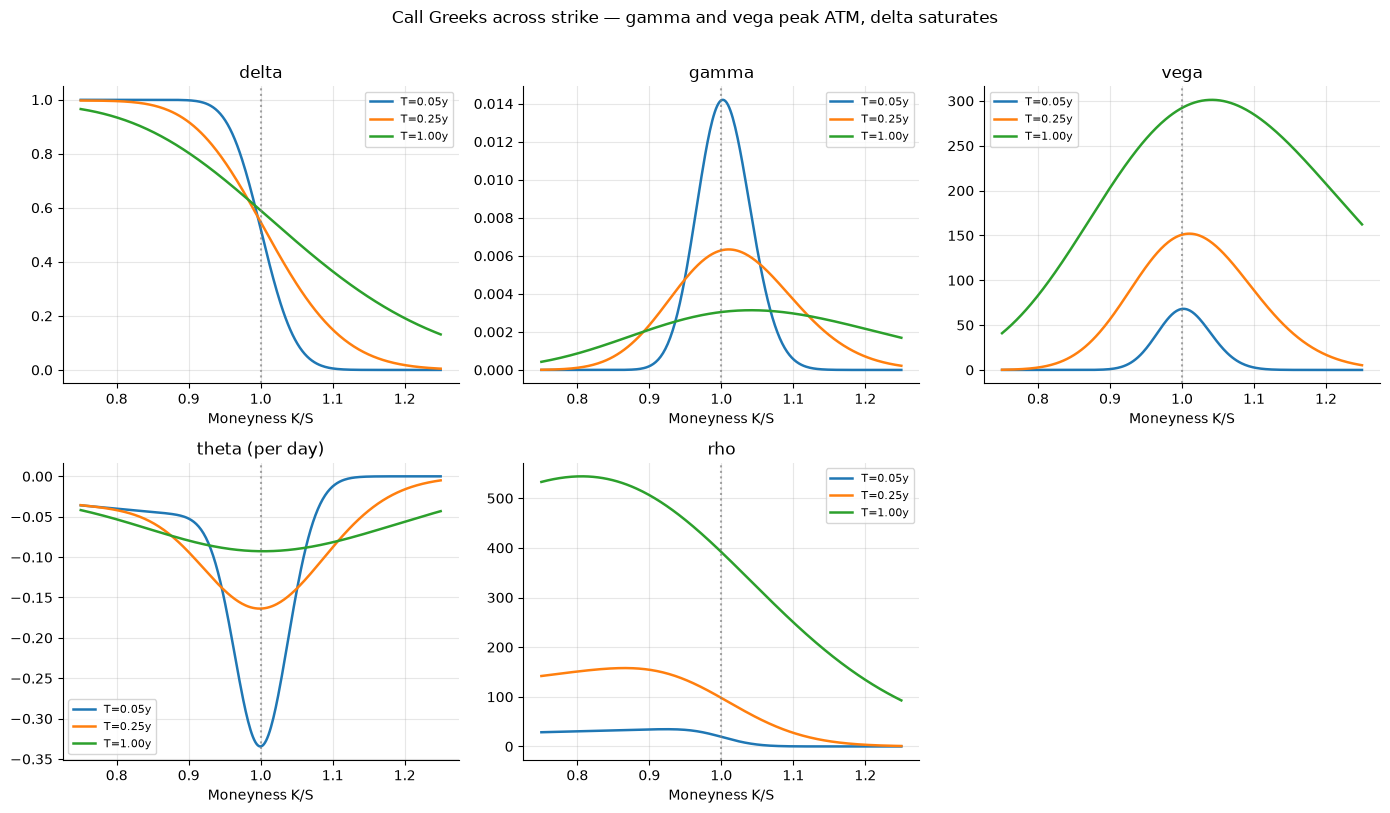

In [88]:
maturities = [0.05, 0.25, 1.0]        # ~2.5 weeks, 3 months, 1 year
Ks = np.linspace(0.75 * S0, 1.25 * S0, 300)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, gname in enumerate(["delta", "gamma", "vega", "theta", "rho"]):
    ax = axes.flat[i]
    for T_ in maturities:
        vals = bs_greeks(S0, Ks, T_, r0, realized_vol, q0, "call")[gname]
        if gname == "theta":
            vals = vals / 365.0            # per calendar day, as traders quote it
        ax.plot(Ks / S0, vals, lw=1.8, label=f"T={T_:.2f}y")
    ax.axvline(1.0, color="grey", ls=":", alpha=0.7)
    ax.set_title(gname + (" (per day)" if gname == "theta" else ""))
    ax.set_xlabel("Moneyness K/S")
    ax.legend(fontsize=8)
axes.flat[5].axis("off")
fig.suptitle("Call Greeks across strike — gamma and vega peak ATM, delta saturates", y=1.01)
plt.tight_layout()
plt.show()

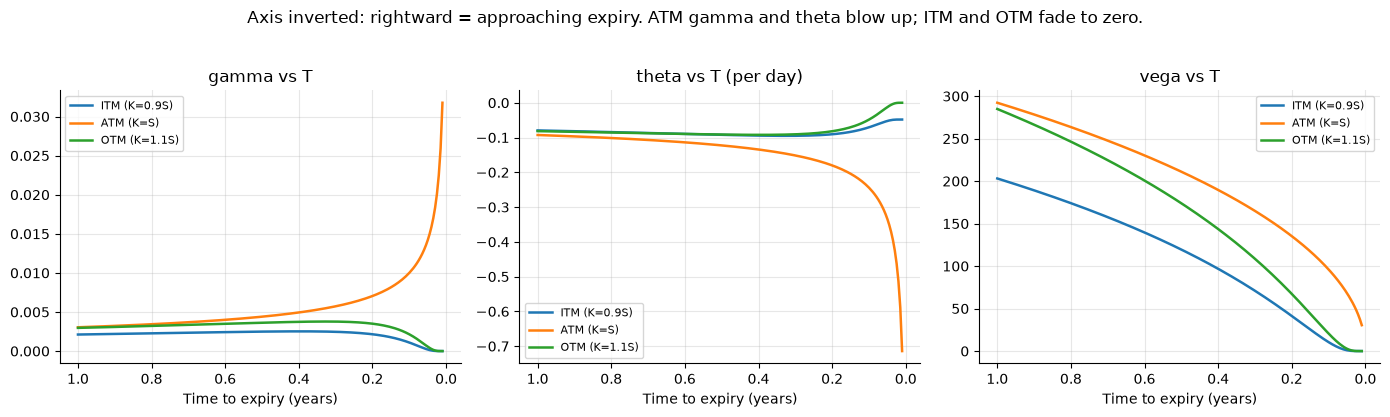

In [89]:
# The ATM gamma/theta explosion near expiry, why short-dated ATM options are
# the most dangerous instruments on a book.
Ts = np.linspace(0.01, 1.0, 200)
scenarios = {"ITM (K=0.9S)": 0.9 * S0, "ATM (K=S)": S0, "OTM (K=1.1S)": 1.1 * S0}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, gname in zip(axes, ["gamma", "theta", "vega"]):
    for label, K_ in scenarios.items():
        vals = bs_greeks(S0, K_, Ts, r0, realized_vol, q0, "call")[gname]
        if gname == "theta":
            vals = vals / 365.0
        ax.plot(Ts, vals, lw=1.8, label=label)
    ax.set_xlabel("Time to expiry (years)")
    ax.set_title(f"{gname} vs T" + (" (per day)" if gname == "theta" else ""))
    ax.invert_xaxis()
    ax.legend(fontsize=8)
fig.suptitle("Axis inverted: rightward = approaching expiry. ATM gamma and theta blow up; "
             "ITM and OTM fade to zero.", y=1.03)
plt.tight_layout()
plt.show()

## 5. Implied volatility

Invert the model: take the **market price** as given and solve for the $\sigma$ that reproduces it. That number is the *implied volatility*, the market's volatility forecast, expressed in the model's own units.

**Why it matters more than the price:**

1. **It's the only comparable quote.** Dollar prices aren't comparable across strikes and expiries; implied vols are. Desks quote, negotiate and think in vol.
2. **It's forward-looking.** Realised vol says what happened; implied says what the market pays to insure against. The gap, *variance risk premium*, is one of the most studied objects in the literature: implied typically exceeds subsequently realised, which is why systematically selling volatility earns a premium, until it very much doesn't.
3. **It's where the model's failure becomes data.** If Black–Scholes were right, implied vol would be one flat number across all strikes and expiries. It isn't, and the *shape* of the deviation says precisely how the market disagrees with log-normality.

**The numerics.** No closed-form inverse exists, so we root-find: Newton–Raphson using vega as the analytical derivative (quadratic convergence, typically 3–6 iterations), with bisection fallback (slow but cannot fail on a bracketed root).

The solver has one failure mode that is deliberate rather than accidental. When an option is deep in the money relative to its remaining volatility, meaning $|\ln(S/K)|$ is large compared to $\sigma\sqrt{T}$, its price equals discounted intrinsic value to machine precision. Vega is then numerically zero, so the price carries no information about volatility, and no solver can recover it: every candidate $\sigma$ reprices the option within tolerance. The honest output is `nan`, not a confident number.

This is also why `build_iv_surface` uses OTM quotes only. An OTM option has no intrinsic value, so its entire premium is time value, which makes it pure volatility information.

In [90]:
# Round trip: price at a known vol, then recover it, with the Newton trace shown.
true_sigma = 0.23
demo_price = float(bs_price(S0, 1.05 * S0, 0.25, r0, true_sigma, q0))
print(f"Price of a 5% OTM 3M call at sigma={true_sigma}: ${demo_price:.2f}")
print("Newton-Raphson trace:")
iv = implied_vol(demo_price, S0, 1.05 * S0, 0.25, r0, q0, verbose=True)
print(f"Recovered IV: {iv:.8f}\n")

# The degenerate case, shown explicitly so the failure mode is understood.
deep_price = float(bs_price(S0, 0.5 * S0, 0.05, r0, 0.20, q0))
deep_vega = float(bs_greeks(S0, 0.5 * S0, 0.05, r0, 0.20, q0)["vega"])
print(f"Deep ITM, short-dated: price=${deep_price:.4f}, vega={deep_vega:.2e}")
print(f"Solver returns {implied_vol(deep_price, S0, 0.5*S0, 0.05, r0, q0):.4f}")
print("\nEvery candidate sigma reprices this option within tolerance, so implied vol")
print("is not identifiable. The solver detects this and refuses rather than")
print("returning an arbitrary point from a flat objective.")

Price of a 5% OTM 3M call at sigma=0.23: $21.68
Newton-Raphson trace:
  NR iter 0: sigma=0.23078810  price_err=+1.030e+01
  NR iter 1: sigma=0.23000017  price_err=+1.143e-01
  NR iter 2: sigma=0.23000000  price_err=+2.533e-05
  NR iter 3: sigma=0.23000000  price_err=+1.194e-12
Recovered IV: 0.23000000

Deep ITM, short-dated: price=$382.4278, vega=2.06e-51
Solver returns nan

Every candidate sigma reprices this option within tolerance, so implied vol
is not identifiable. The solver detects this and refuses rather than
returning an arbitrary point from a flat objective.


## 6. Pricing-method comparison

Why use numerical methods when a closed form exists? Because the closed form exists **only** for this narrow case; European vanilla, GBM, constant everything. Change one thing (early exercise -> tree; path dependence or multiple underlyings -> Monte Carlo) and the formula dies.

The European vanilla is the one contract all three methods price, which makes it the natural regression test: **if a tree or an MC estimator doesn't converge to Black–Scholes here, it's wrong everywhere else too.**

- **Binomial (Cox–Ross–Rubinstein).** Discretise time; the price moves up by $u = e^{\sigma\sqrt{\Delta t}}$ or down by $d = 1/u$ with risk-neutral probability $p = \frac{e^{(r-q)\Delta t} - d}{u-d}$; discount payoffs backwards. Error is $O(1/n)$ with a characteristic oscillation as the strike falls between nodes.
- **Monte Carlo.** Simulate $S_T = S_0 e^{(r-q-\sigma^2/2)T + \sigma\sqrt{T}Z}$ and average discounted payoffs. Standard error is $O(1/\sqrt{N})$. This is brutally slow, which is why variance reduction matters.
- **Antithetic variates.** Pair each draw $Z$ with $-Z$ and average. The payoffs are negatively correlated, so the pair-average has lower variance than two independent draws. One line of code, free accuracy.

In [91]:
K_test, T_test, sig_test = S0, 0.25, realized_vol       # 3M ATM SPY call
exact = float(bs_price(S0, K_test, T_test, r0, sig_test, q0))
tree = binomial_price(S0, K_test, T_test, r0, sig_test, q0, steps=500)
mc = mc_price(S0, K_test, T_test, r0, sig_test, q0, n_paths=400_000, seed=1)

print(f"Closed-form BS:            ${exact:.4f}")
print(f"Binomial, 500 steps:       ${tree:.4f}   (error {tree - exact:+.4f})")
print(f"MC antithetic, 400k paths: ${mc.price:.4f}   (error {mc.price - exact:+.4f}, SE {mc.stderr:.4f})")
print(f"MC 95% CI: [{mc.ci95[0]:.4f}, {mc.ci95[1]:.4f}]  contains exact: {mc.ci95[0] <= exact <= mc.ci95[1]}")

Closed-form BS:            $27.5222
Binomial, 500 steps:       $27.5097   (error -0.0125)
MC antithetic, 400k paths: $27.4628   (error -0.0594, SE 0.0461)
MC 95% CI: [27.3725, 27.5531]  contains exact: True


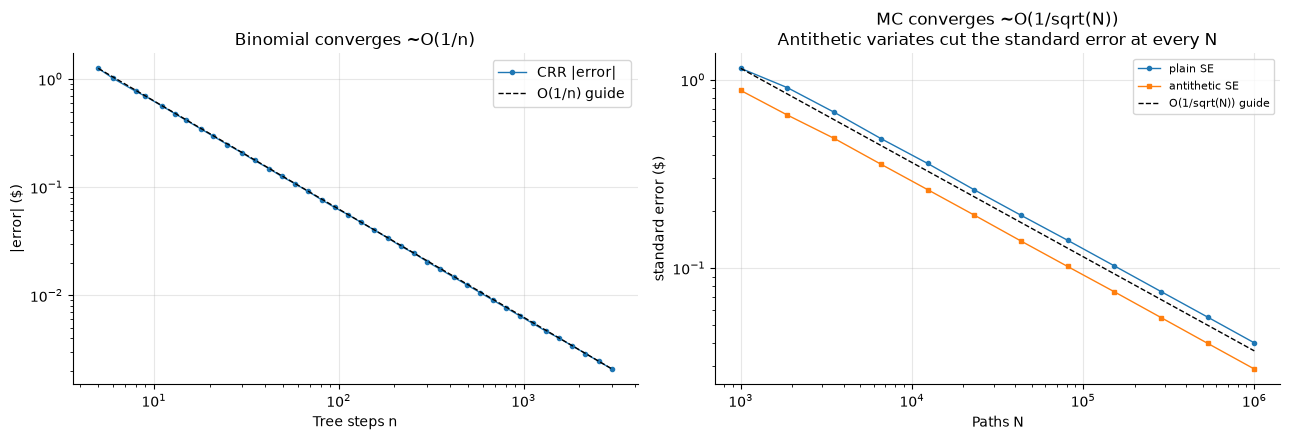

Average SE reduction from antithetic variates: 1.37x at equal path count

Convergence: BS=27.5222  tree(3000)=27.5201  MC(1M)=27.5280


In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Binomial: error vs steps
step_grid = np.unique(np.geomspace(5, 3000, 40).astype(int))
tree_err = [abs(binomial_price(S0, K_test, T_test, r0, sig_test, q0, steps=int(n)) - exact)
            for n in step_grid]
axes[0].loglog(step_grid, tree_err, "o-", ms=3, lw=1, label="CRR |error|")
axes[0].loglog(step_grid, tree_err[0] * step_grid[0] / step_grid, "k--", lw=1, label="O(1/n) guide")
axes[0].set_xlabel("Tree steps n")
axes[0].set_ylabel("|error| ($)")
axes[0].set_title("Binomial converges ~O(1/n)")
axes[0].legend()


# Monte Carlo: plain vs antithetic
path_grid = np.geomspace(1_000, 1_000_000, 12).astype(int)
se_p, se_a = [], []
for n in path_grid:
    se_p.append(mc_price(S0, K_test, T_test, r0, sig_test, q0, n_paths=int(n), antithetic=False, seed=7).stderr)
    se_a.append(mc_price(S0, K_test, T_test, r0, sig_test, q0, n_paths=int(n), antithetic=True, seed=7).stderr)
axes[1].loglog(path_grid, se_p, "o-", ms=3, lw=1, label="plain SE")
axes[1].loglog(path_grid, se_a, "s-", ms=3, lw=1, label="antithetic SE")
axes[1].loglog(path_grid, se_p[0] * np.sqrt(path_grid[0] / path_grid), "k--", lw=1, label="O(1/sqrt(N)) guide")
axes[1].set_xlabel("Paths N"); axes[1].set_ylabel("standard error ($)")
axes[1].set_title("MC converges ~O(1/sqrt(N))\nAntithetic variates cut the standard error at every N")
axes[1].legend(fontsize=8)
plt.tight_layout() 
plt.show()


print(f"Average SE reduction from antithetic variates: "
      f"{np.mean(np.array(se_p) / np.array(se_a)):.2f}x at equal path count")
print(f"\nConvergence: BS={exact:.4f}  "
      f"tree(3000)={binomial_price(S0, K_test, T_test, r0, sig_test, q0, steps=3000):.4f}  "
      f"MC(1M)={mc_price(S0, K_test, T_test, r0, sig_test, q0, n_paths=1_000_000, seed=3).price:.4f}")

## 7. The implied volatility surface

Now the punchline. Compute implied vol from **real SPY option prices** across strikes and expiries. If Black–Scholes were the truth, this would be a flat plane at one number. Instead, index options show:

- **Skew.** OTM puts trade at *much* higher implied vols than OTM calls. The market pays up for crash protection, a feature institutionalised after October 1987, before which the curve was roughly flat. Two standard explanations: genuine negative-jump risk (the left tail is fat), and the *leverage effect* (volatility rises as prices fall, so low strikes are reached in high-vol states).
- **Convexity.** The curve bends upward in log-moneyness. Worth stating precisely, because the folk description is wrong: for an equity index the skew term dominates, so implied vol is close to **monotonically decreasing in strike** across the liquid range. Both wings sitting above ATM is a currency-market phenomenon rather than an index one. What survives for indices is the convexity, which is what any fitted parameterisation must capture.
- **Term structure.** Short-dated ATM vol is more volatile and event-sensitive; long-dated vol anchors nearer long-run averages. Skew is steepest at the front.

**Data hygiene matters more than the maths here.** yfinance quotes are delayed, unsynchronised with spot and full of junk. So `build_iv_surface` filters to OTM options only, requires a live bid, drops relative bid–ask spreads above 40%, drops sub-10-day expiries (microstructure noise, pin risk), and uses mid rather than the stale `lastPrice`. Even so, treat this as illustrative: a desk would use synchronised tick data, a proper forward curve, and an arbitrage-free fit such as SVI.

In [93]:
surf, surface_live = build_iv_surface(snap)
print(f"Surface points: {len(surf)}")
print(f"Expiries (years): {sorted(surf['T'].round(3).unique())}")
print(f"Source: {'live SPY option chains' if surface_live else 'SYNTHETIC fallback'}")
surf.head()

Surface points: 790
Expiries (years): [np.float64(0.036), np.float64(0.093), np.float64(0.216), np.float64(0.381), np.float64(0.762), np.float64(1.359)]
Source: live SPY option chains


,T,moneyness,iv,kind
0,0.035616,0.752332,0.561009,put
1,0.035616,0.758874,0.545467,put
2,0.035616,0.765416,0.536962,put
3,0.035616,0.771958,0.527657,put
4,0.035616,0.778500,0.512096,put


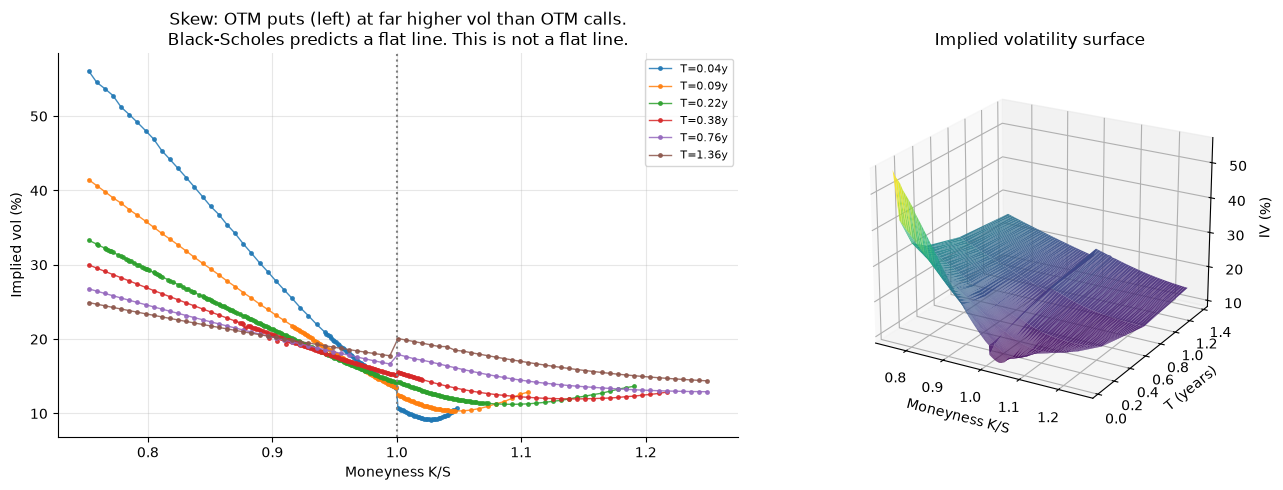

In [94]:
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
for T_e, grp in surf.groupby("T"):
    ax1.plot(grp["moneyness"], grp["iv"] * 100, "o-", ms=2.5, lw=1, alpha=0.85, label=f"T={T_e:.2f}y")
ax1.axvline(1.0, color="grey", ls=":")
ax1.set_xlabel("Moneyness K/S"); ax1.set_ylabel("Implied vol (%)")
ax1.set_title("Skew: OTM puts (left) at far higher vol than OTM calls.\n"
              "Black-Scholes predicts a flat line. This is not a flat line.")
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.plot_trisurf(surf["moneyness"], surf["T"], surf["iv"] * 100,
                 cmap="viridis", alpha=0.9, linewidth=0.1)
ax2.set_xlabel("Moneyness K/S"); ax2.set_ylabel("T (years)"); ax2.set_zlabel("IV (%)")
ax2.set_title("Implied volatility surface")
ax2.view_init(elev=22, azim=-60)
plt.tight_layout()
plt.show()

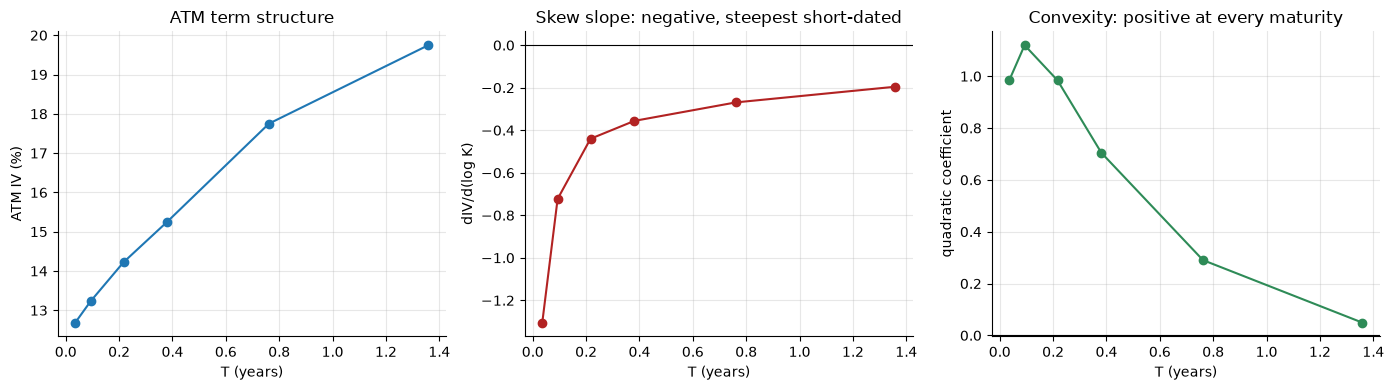

     T  atm_iv  skew_slope  convexity
0.0356  0.1269     -1.3048     0.9843
0.0932  0.1323     -0.7230     1.1196
0.2164  0.1422     -0.4401     0.9841
0.3808  0.1526     -0.3559     0.7045
0.7616  0.1775     -0.2689     0.2904
1.3589  0.1975     -0.1953     0.0493


In [95]:
# ATM term structure, skew steepness, and convexity by maturity
rows = []
for T_e, grp in surf.groupby("T"):
    grp = grp.sort_values("moneyness")
    atm = np.interp(1.0, grp["moneyness"], grp["iv"])
    k = np.log(grp["moneyness"])
    quad, lin, _ = np.polyfit(k, grp["iv"], 2) if len(grp) >= 5 else (np.nan, np.nan, np.nan)
    rows.append((T_e, atm, lin, quad))
ts = pd.DataFrame(rows, columns=["T", "atm_iv", "skew_slope", "convexity"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(ts["T"], ts["atm_iv"] * 100, "o-")
axes[0].set_xlabel("T (years)"); axes[0].set_ylabel("ATM IV (%)"); axes[0].set_title("ATM term structure")
axes[1].plot(ts["T"], ts["skew_slope"], "o-", color="firebrick")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xlabel("T (years)"); axes[1].set_ylabel("dIV/d(log K)")
axes[1].set_title("Skew slope: negative, steepest short-dated")
axes[2].plot(ts["T"], ts["convexity"], "o-", color="seagreen")
axes[2].axhline(0, color="k", lw=0.8)
axes[2].set_xlabel("T (years)"); axes[2].set_ylabel("quadratic coefficient")
axes[2].set_title("Convexity: positive at every maturity")
plt.tight_layout()
plt.show()
print(ts.round(4).to_string(index=False))

## 8. What breaks in reality

The surface above is the market's rejection notice for assumption 1. The full damage report:

**1. Volatility is not constant, it isn't even a single number *today*.** The skew means the market prices *different* vols for different strikes on the *same underlying over the same period*, which is internally inconsistent with the model's premise. Volatility also clusters in time (the entire GARCH literature) and is itself stochastic, what Heston (1993), SABR and local-vol models exist to fix.

**2. Returns have fat tails.** Extreme moves happen orders of magnitude more often than a normal distribution permits. Under normality a daily move beyond 4σ should occur roughly once every ~63 years of trading; SPY produces them routinely. 19 October 1987 was a 20σ+ event under normality, an incredibly tiny probability, and 2008, 2015, 2018, 2020 and the 2024 yen-carry unwind each delivered further "impossible" days. The normal density decays like $e^{-x^2/2}$; real return tails decay like a power law. Every risk number built on normality is quietly wrong in exactly the states where it matters.

**3. Prices jump.** GBM has continuous paths, so a delta hedge can always be adjusted on the way down. Real prices gap (overnight, on news, at the open) and no hedge can be rebalanced through a gap. This is precisely what the put skew charges for; Merton's (1976) jump-diffusion was the first patch.

**4. Hedging is discrete and costly.** Continuous rebalancing is a fiction. Real hedging happens at intervals, pays spreads and fees, and leaves residual gamma risk. Leland (1985) showed transaction costs effectively widen the volatility you should price at.

**5. The rest of the fine print.** Rates aren't constant (post-2022, rho stopped being ignorable); dividends are discrete lumps, not a continuous yield; shorting has costs; most single-name options are American.

**So why does everyone still use it?** Because it's an excellent *coordinate system*. A monotone map from price to vol, exact hedging intuition, closed-form Greeks, and every deviation from reality absorbed into one free parameter that the market then quotes directly. Black–Scholes is wrong the way a flat map projection is wrong: everyone knows, everyone corrects for it but nobody navigates without it.

n = 500 daily returns | excess kurtosis 20.26 (normal: 0) | skew 0.84
Jarque-Bera p = 0.000e+00 -> normality REJECTED

|move| > 3 sigma: observed   5  |  normal predicts   1.350  (3.7x expected)
|move| > 4 sigma: observed   4  |  normal predicts   0.032  (126.3x expected)
|move| > 5 sigma: observed   2  |  normal predicts   0.000  (6977.1x expected)


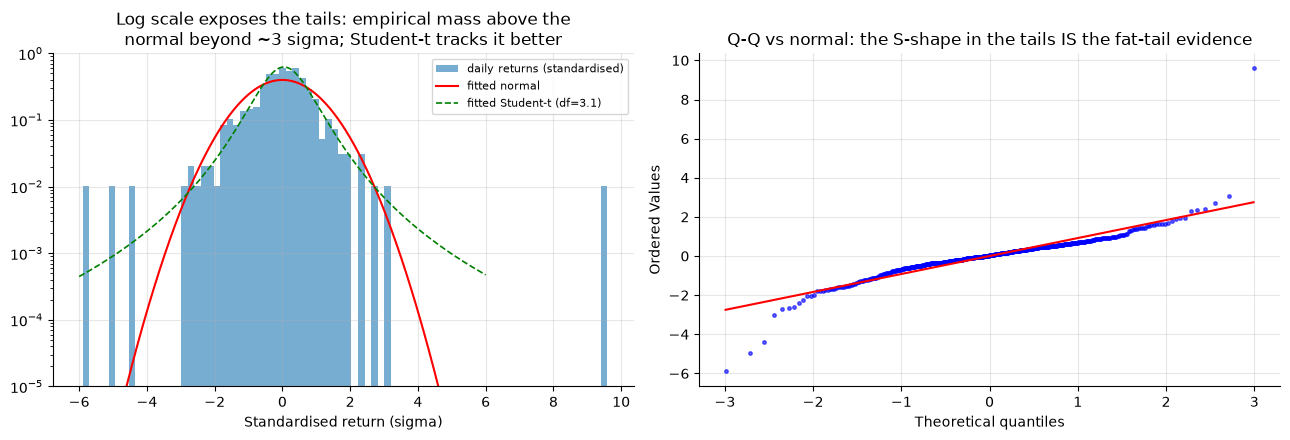

In [96]:
# Fat tails, measured on the underlying's own daily log returns
z = ((log_ret - log_ret.mean()) / log_ret.std()).values
n = len(z)

if not snap.live:
    print("NOTE: running on the synthetic GBM fallback, whose returns are normal BY")
    print("CONSTRUCTION. This cell will correctly find nothing. Run with live SPY data")
    print("to see real excess kurtosis (typically 5-15 on daily returns).\n")

print(f"n = {n} daily returns | excess kurtosis {stats.kurtosis(z):.2f} (normal: 0) | "
      f"skew {stats.skew(z):.2f}")
jb_stat, jb_p = stats.jarque_bera(z)
print(f"Jarque-Bera p = {jb_p:.3e} -> "
      f"{'normality REJECTED' if jb_p < 0.01 else 'cannot reject normality'}\n")

for t in [3, 4, 5]:
    observed = int((np.abs(z) > t).sum())
    expected = 2 * (1 - stats.norm.cdf(t)) * n
    ratio = f"{observed / expected:.1f}x expected" if expected > 1e-6 else "n/a"
    print(f"|move| > {t} sigma: observed {observed:>3}  |  normal predicts {expected:7.3f}  ({ratio})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(z, bins=80, density=True, alpha=0.6, label="daily returns (standardised)")
xs = np.linspace(-6, 6, 400)
axes[0].plot(xs, stats.norm.pdf(xs), "r-", lw=1.5, label="fitted normal")
df_t, loc_t, scale_t = stats.t.fit(z)
axes[0].plot(xs, stats.t.pdf(xs, df_t, loc_t, scale_t), "g--", lw=1.2,
             label=f"fitted Student-t (df={df_t:.1f})")
axes[0].set_yscale("log"); axes[0].set_ylim(1e-5, 1)
axes[0].set_xlabel("Standardised return (sigma)")
axes[0].set_title("Log scale exposes the tails: empirical mass above the\nnormal beyond ~3 sigma; Student-t tracks it better")
axes[0].legend(fontsize=8)

stats.probplot(z, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q vs normal: the S-shape in the tails IS the fat-tail evidence")
axes[1].get_lines()[0].set(ms=2.5, alpha=0.6)
plt.tight_layout() 
plt.show()

## 9. Summary and extensions

**Built:** a tested Black–Scholes engine (prices, five analytical Greeks verified against finite differences and against the PDE itself), an implied-vol solver with documented failure modes, three pricing methods shown to converge, a real-data implied vol surface exhibiting index skew, and direct empirical evidence for why the core assumptions fail.

**The takeaway, compressed:** Black–Scholes is not a pricing model in practice, it's just a *quoting and hedging framework*. The market prices options however it prices them; Black–Scholes translates those prices into a common language ($\sigma$-space) where they can be compared, interpolated and risk-managed. The vol surface is simultaneously the model's refutation and the reason it survives.

**Extensions, roughly ascending in difficulty:**

- **American options** - already supported via `binomial_price(..., american=True)`; quantify the early-exercise premium on puts and confirm it vanishes for calls on non-dividend payers.
- **Local volatility (Dupire, 1994)** - a $\sigma(S,t)$ that reprices the entire surface exactly.
- **Stochastic volatility (Heston, 1993)** - vol as a mean-reverting process correlated with spot; generates skew endogenously. Calibrating it to the Section 7 surface is the natural next project.
- **Jump diffusion (Merton, 1976)** - Poisson jumps on top of GBM, aimed directly at the fat-tail failure above.
- **SVI parameterisation (Gatheral)** - an arbitrage-free functional fit per expiry, replacing the raw scatter used here.

**Data caveats, stated plainly:** yfinance option quotes are delayed and unsynchronised with spot; mid-prices from wide markets are noisy; the risk-free rate is a single 13-week bill yield rather than a term-matched curve; the dividend yield is a trailing approximation rather than the market-implied forward yield. All fixable, none fixed here. This project is about the model, not production data engineering.